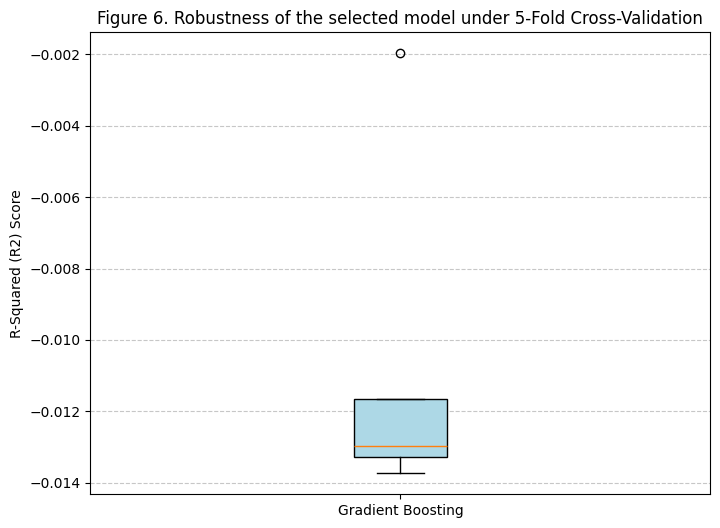

Mean R2: -0.0107
Standard Deviation: 0.0044
RQ6 Complete!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor

# 1. Load & Prep
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')
cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
df_clean = df.drop(columns=cols_to_drop)
df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)

X = df_clean.drop(columns=['Revenue_Generated'])
y = df_clean['Revenue_Generated']

# 2. Cross-Validation Setup
model = GradientBoostingRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Execute CV
cv_results = cross_val_score(model, X, y, cv=kf, scoring='r2')

# 4. Save Table VI Data
cv_summary = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "R2_Score": cv_results
})
cv_summary.to_csv('RQ6_Cross_Validation_Results.csv', index=False)

# 5. Save Figure 6: Boxplot of CV Scores
plt.figure(figsize=(8, 6))
plt.boxplot(cv_results, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Figure 6. Robustness of the selected model under 5-Fold Cross-Validation')
plt.ylabel('R-Squared (R2) Score')
plt.xticks([1], ['Gradient Boosting'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('RQ6_Robustness_Boxplot.pdf')
plt.show()

print(f"Mean R2: {np.mean(cv_results):.4f}")
print(f"Standard Deviation: {np.std(cv_results):.4f}")
print("RQ6 Complete!")